In [1]:
%load_ext autoreload
%autoreload 2

from modules.data_services.data_utils import load_btc_benchmark
from modules.visualization.plots import plot_positions, plot_pnl, plot_zscore
from modules.performance.strategy import Strategy

In [2]:
interval = "1h"
fee_rate = 0.0005
initial_cash = 100000
risk_free_rate = 0

ticker_x = "ETHUSDT"
ticker_y = "UNIUSDT"

pair_selection_start = "2024-01-01"

opt_start = "2024-02-01"
opt_end = "2024-03-01"

test_start = "2024-03-01"
test_end = "2024-04-01"

In [3]:
bt_1 = Strategy(
    ticker_x=ticker_x,
    ticker_y=ticker_y,
    start=pair_selection_start,
    end=test_end,
    interval=interval,
    fee_rate=fee_rate,
    initial_cash=initial_cash,
    risk_free_rate_annual=risk_free_rate,
    window="rolling",
    source="log",
    beta_hedge=None,
)

In [4]:
from skopt.space import Real

static_params = {
    # "stop_loss": 2
}
param_space = [
    Real(0.5, 2, name="window_factor"),
    Real(1.01, 4.00, name="entry_threshold"),
    Real(0.0, 1.00, name="exit_threshold"),
    Real(1.01, 2.00, name="stop_loss"),
]

metric = ("sortino_ratio_annual", "net")

In [5]:
best_params, best_score = bt_1.run_optimization(
    static_params=static_params,
    param_space=param_space,
    metric=metric,
    opt_start=opt_start,
    opt_end=opt_end,
    pair_selection_start=pair_selection_start,
    n_iter=50,
    random_state=42,
    replicates=1,
    penalty_bad=-100,
)

entry_threshold = best_params["entry_threshold"]
exit_threshold = best_params["exit_threshold"]
stop_loss = best_params["stop_loss"]

In [6]:
print(entry_threshold, exit_threshold, stop_loss, window_factor)

In [7]:
opt_1 = bt_1.run_strategy(
    entry_threshold=entry_threshold,
    exit_threshold=exit_threshold,
    stop_loss=stop_loss,
    test_start=opt_start,
    test_end=opt_end,
    pair_selection_start=pair_selection_start,
    window_factor=1,
)

In [8]:
plot_positions(opt_1, show=True)
btc_data = load_btc_benchmark(
    test_start=opt_start,
    test_end=opt_end,
    interval=interval,
)
plot_pnl(opt_1, btc_data, show=True)
plot_zscore(opt_1, show=True, sl_thr=True)

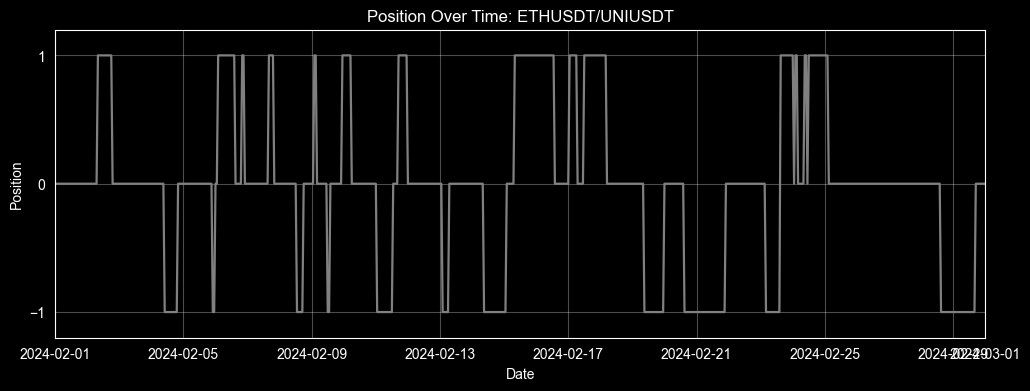

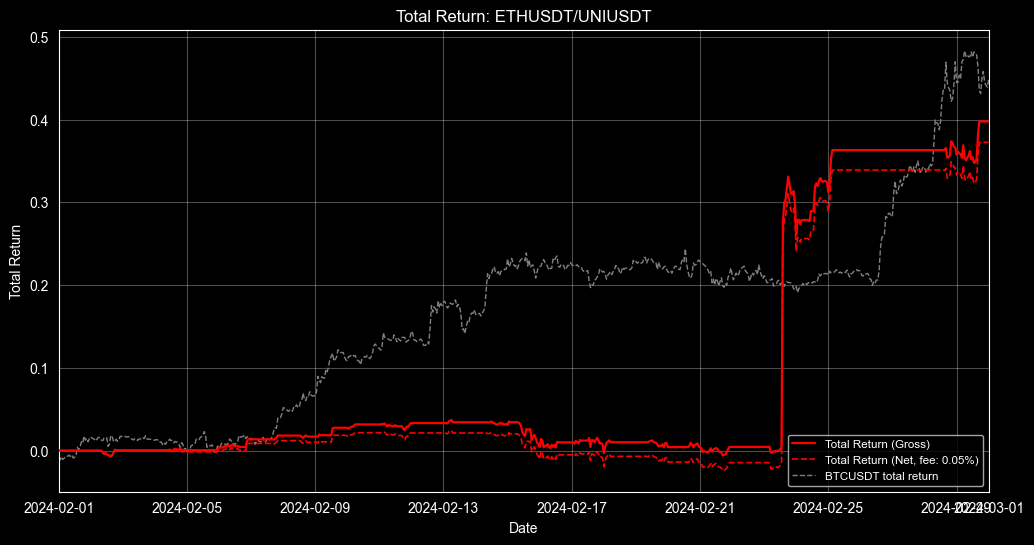

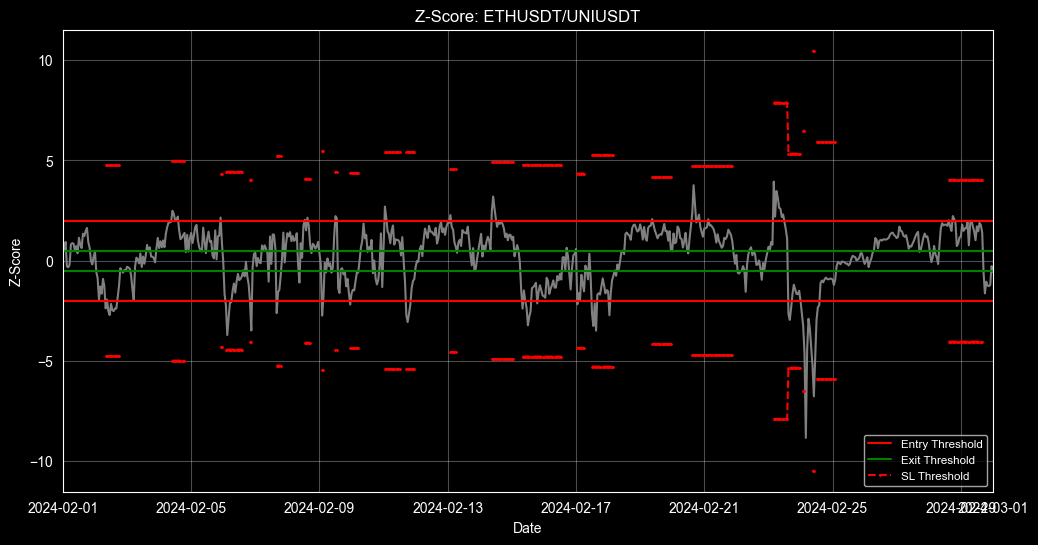

In [9]:
# opt_1.data

In [10]:
opt_1.stats

In [11]:
result_1 = bt_1.run_strategy(
    entry_threshold=entry_threshold,
    exit_threshold=exit_threshold,
    stop_loss=stop_loss,
    test_start=test_start,
    test_end=test_end,
    pair_selection_start=pair_selection_start,
    window_factor=window_factor,
)

,gross,net
metric,,
total_return,0.3978,0.3726
cagr,66.2673,52.5265
volatility,0.0107,0.0109
volatility_annual,0.9979,1.0173
max_drawdown,-0.0524,-0.0533
win_count,18.0000,14.0000
lose_count,7.0000,11.0000
win_rate,0.7200,0.5600
max_win,0.2947,0.2936


In [12]:
plot_positions(result_1, show=True)
btc_data = load_btc_benchmark(
    test_start=test_start,
    test_end=test_end,
    interval=interval,
)
plot_pnl(result_1, btc_data, show=True)
plot_zscore(result_1, show=True, sl_thr=True)

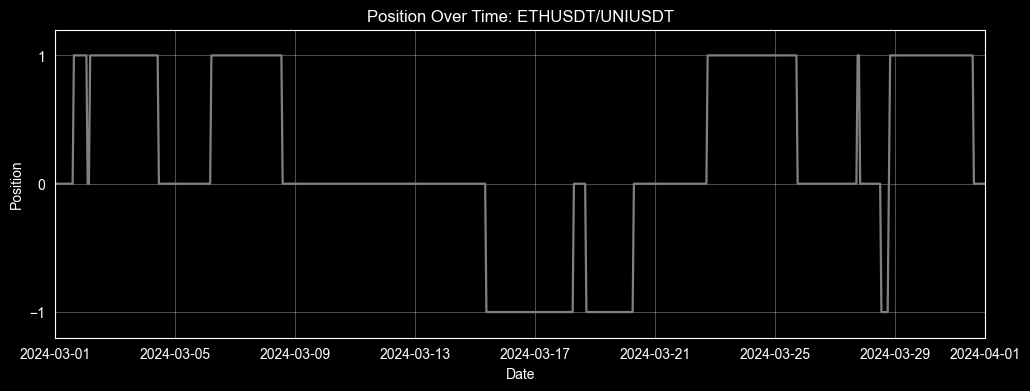

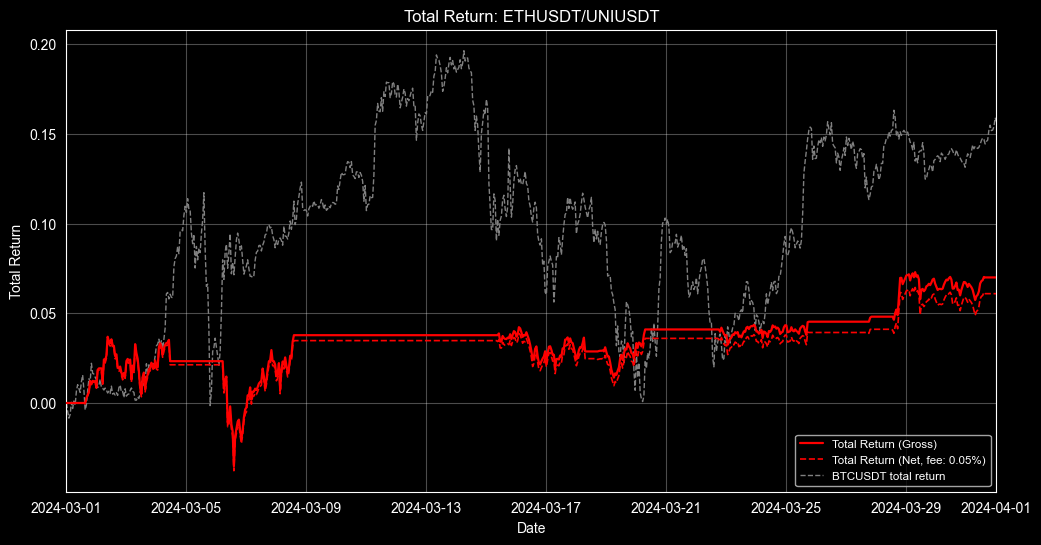

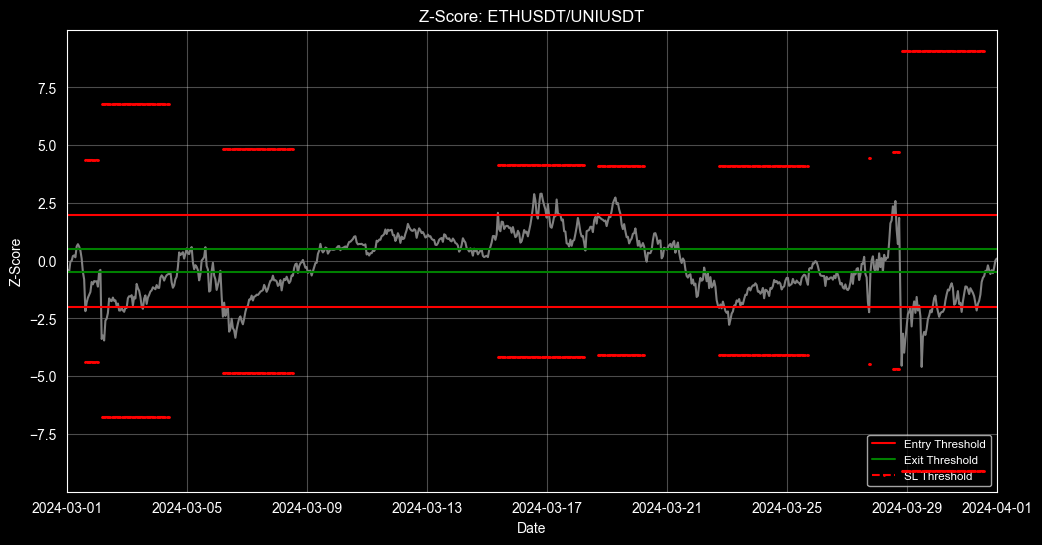

In [13]:
# result_1.data

In [14]:
result_1.stats

In [15]:
result_1.stats

,gross,net
metric,,
total_return,0.0700,0.0609
cagr,1.2151,1.0047
volatility,0.0029,0.0029
volatility_annual,0.2726,0.2735
max_drawdown,-0.0696,-0.0707
win_count,8.0000,7.0000
lose_count,1.0000,2.0000
win_rate,0.8889,0.7778
max_win,0.0216,0.0211


In [16]:
result_1.data

,ETHUSDT,UNIUSDT,z_score,window,beta,entry_thr,exit_thr,sl_thr,q_x,q_y,w_x,w_y,signal,position,total_return,total_fees,net_return,total_return_pct,net_return_pct
open_time,,,,,,,,,,,,,,,,,,,
2024-03-01 00:00:00,3378.73,11.212,-0.536856,77.0,1.0,2.0,0.5,None,0.0,0.0,None,None,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-03-01 01:00:00,3375.20,11.221,-0.402411,77.0,1.0,2.0,0.5,None,0.0,0.0,None,None,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-03-01 02:00:00,3366.73,11.060,-0.466159,77.0,1.0,2.0,0.5,None,0.0,0.0,None,None,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-03-01 03:00:00,3367.79,11.051,-0.038836,76.0,1.0,2.0,0.5,None,0.0,0.0,None,None,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-03-01 04:00:00,3376.87,11.015,-0.006289,76.0,1.0,2.0,0.5,None,0.0,0.0,None,None,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-31 20:00:00,3633.25,13.022,-0.41051,143.0,1.0,2.0,0.5,None,0.0,0.0,None,None,0.0,0.0,6997.801999,904.348038,6093.453961,0.069978,0.060935
2024-03-31 21:00:00,3625.32,12.945,-0.53971,143.0,1.0,2.0,0.5,None,0.0,0.0,None,None,0.0,0.0,6997.801999,904.348038,6093.453961,0.069978,0.060935
2024-03-31 22:00:00,3629.80,12.906,-0.288328,143.0,1.0,2.0,0.5,None,0.0,0.0,None,None,0.0,0.0,6997.801999,904.348038,6093.453961,0.069978,0.060935
